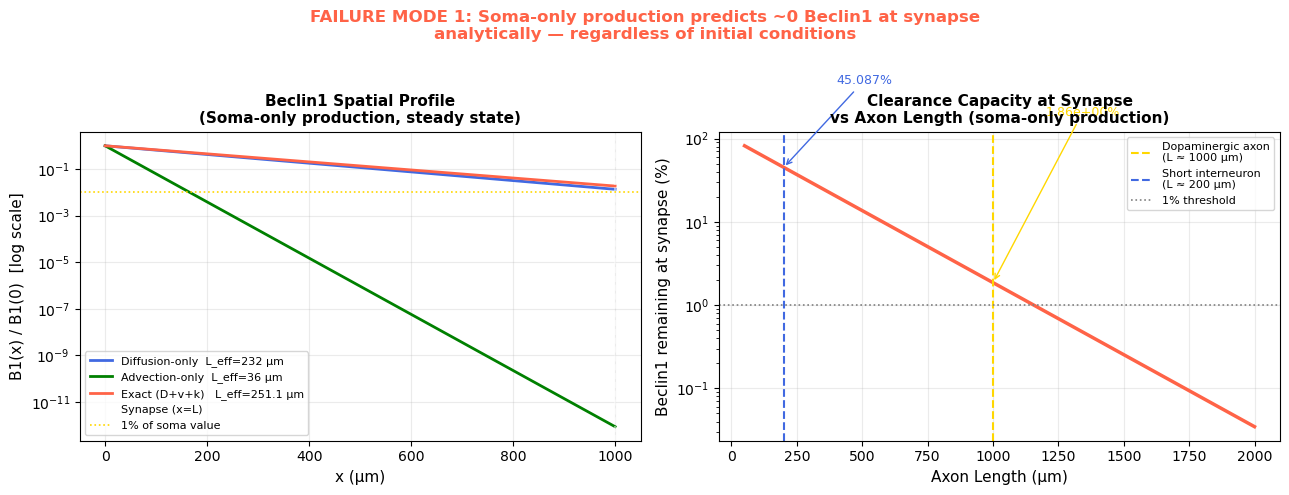

=== Analytical decay lengths ===
  Diffusion-dominated:  L_eff = 232.4 µm
  Advection-dominated:  L_eff = 36.0 µm
  Exact (D + v + k):    L_eff = 251.08 µm

=== Fraction of Beclin1 surviving to synapse ===
  L=200  µm (short axon):  45.0871%
  L=1000 µm (dopamine):    1.86e+00%
  L=1500 µm (long axon):   2.54e-01%

Conclusion: soma-only production leaves ZERO clearance capacity
at the synapse — autophagy is structurally disabled by the equation.


In [1]:
# === Cell A1: Why soma-only Beclin1 production fails analytically ===
# At steady state with no local production, the 1D advection-diffusion-decay equation:
#   D·d²B/dx² - v·dB/dx - k_eff·B = 0
# has solution B(x) = B0 · exp(-x / L_eff)
# where L_eff = characteristic decay length

import numpy as np
import matplotlib.pyplot as plt

# Parameters
D_B1  = 5.4e4    # µm²/h
vB    = 36.0     # µm/h
k15   = 1.0      # h⁻¹ (dominant inactivation rate)
L     = 1000.0   # µm

# Two estimates of effective decay length
# 1. Diffusion-dominated: L_eff = sqrt(D/k)
L_eff_diff = np.sqrt(D_B1 / k15)

# 2. Advection-dominated: L_eff = v/k
L_eff_adv  = vB / k15

# 3. Combined (exact solution of ODE)
# Characteristic equation: D·r² - v·r - k = 0
# r = (v - sqrt(v² + 4Dk)) / (2D)  [negative root for decaying solution]
discriminant = vB**2 + 4 * D_B1 * k15
r_neg = (vB - np.sqrt(discriminant)) / (2 * D_B1)
L_eff_exact = -1.0 / r_neg

x_vals = np.linspace(0, L, 500)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# --- Left: spatial profiles for different assumptions ---
ax = axes[0]
profiles = {
    f'Diffusion-only  L_eff={L_eff_diff:.0f} µm': np.exp(-x_vals / L_eff_diff),
    f'Advection-only  L_eff={L_eff_adv:.0f} µm':  np.exp(-x_vals / L_eff_adv),
    f'Exact (D+v+k)   L_eff={L_eff_exact:.1f} µm': np.exp(r_neg * x_vals),
}
colors = ['royalblue', 'green', 'tomato']
for (label, profile), col in zip(profiles.items(), colors):
    ax.semilogy(x_vals, profile, color=col, lw=2, label=label)

ax.axvline(L, color='white', ls='--', lw=1.2, alpha=0.6, label='Synapse (x=L)')
ax.axhline(0.01, color='gold', ls=':', lw=1.2, label='1% of soma value')
ax.set_xlabel('x (µm)', fontsize=11)
ax.set_ylabel('B1(x) / B1(0)  [log scale]', fontsize=11)
ax.set_title('Beclin1 Spatial Profile\n(Soma-only production, steady state)',
             fontsize=11, fontweight='bold')
ax.legend(fontsize=8)
ax.grid(alpha=0.25)

# --- Right: fraction remaining at synapse vs axon length ---
ax2 = axes[1]
L_range = np.linspace(50, 2000, 300)
frac_exact = np.exp(r_neg * L_range)

ax2.semilogy(L_range, frac_exact * 100, 'tomato', lw=2.5)
ax2.axvline(1000, color='gold', ls='--', lw=1.5,
            label='Dopaminergic axon\n(L ≈ 1000 µm)')
ax2.axvline(200,  color='royalblue', ls='--', lw=1.5,
            label='Short interneuron\n(L ≈ 200 µm)')
ax2.axhline(1.0, color='gray', ls=':', lw=1.2, label='1% threshold')

# Annotate actual values
frac_1000 = np.exp(r_neg * 1000) * 100
frac_200  = np.exp(r_neg * 200)  * 100
ax2.annotate(f'{frac_1000:.2e}%', xy=(1000, frac_1000),
             xytext=(1200, frac_1000*100),
             color='gold', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='gold'))
ax2.annotate(f'{frac_200:.3f}%', xy=(200, frac_200),
             xytext=(400, frac_200*10),
             color='royalblue', fontsize=9,
             arrowprops=dict(arrowstyle='->', color='royalblue'))

ax2.set_xlabel('Axon Length (µm)', fontsize=11)
ax2.set_ylabel('Beclin1 remaining at synapse (%)', fontsize=11)
ax2.set_title('Clearance Capacity at Synapse\nvs Axon Length (soma-only production)',
              fontsize=11, fontweight='bold')
ax2.legend(fontsize=8)
ax2.grid(alpha=0.25)

plt.suptitle('FAILURE MODE 1: Soma-only production predicts ~0 Beclin1 at synapse\n'
             'analytically — regardless of initial conditions',
             fontsize=12, fontweight='bold', color='tomato')
plt.tight_layout()
plt.savefig('failure_1_transport.png', dpi=150)
plt.show()

print("=== Analytical decay lengths ===")
print(f"  Diffusion-dominated:  L_eff = {L_eff_diff:.1f} µm")
print(f"  Advection-dominated:  L_eff = {L_eff_adv:.1f} µm")
print(f"  Exact (D + v + k):    L_eff = {L_eff_exact:.2f} µm")
print(f"\n=== Fraction of Beclin1 surviving to synapse ===")
print(f"  L=200  µm (short axon):  {np.exp(r_neg*200)*100:.4f}%")
print(f"  L=1000 µm (dopamine):    {np.exp(r_neg*1000)*100:.2e}%")
print(f"  L=1500 µm (long axon):   {np.exp(r_neg*1500)*100:.2e}%")
print(f"\nConclusion: soma-only production leaves ZERO clearance capacity")
print(f"at the synapse — autophagy is structurally disabled by the equation.")

In [2]:
# === Cell A2: IC doesn't matter — the equation drives B1 to zero ===
# Test three very different Beclin1 ICs — all converge to the same wrong SS

from scipy.integrate import solve_ivp

# Three ICs: low, medium, high Beclin1
B1_IC_sets = {
    'Low IC: B1=0.01 (near zero)':    np.full(Nx, 0.01),
    'Medium IC: B1=0.37 (half pool)': np.full(Nx, 0.37),
    'High IC: B1=0.73 (ODE SS)':      np.full(Nx, 0.73),
}
colors_ic = ['royalblue', 'gold', 'tomato']

T_test = 30.0
t_test = np.linspace(0, T_test, 300)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for (ic_label, B1_ic), col in zip(B1_IC_sets.items(), colors_ic):
    # Build y0 with this B1 IC, everything else standard
    y0_test = np.concatenate([ROS0, Asol0, np.zeros(Nx),
                              np.zeros(Nx), mTOR0, B1_ic, Casp0])
    sol_test = solve_ivp(
        pde_rhs, (0, T_test), y0_test,
        method='Radau', t_eval=t_test,
        args=(p, TR, x, dx, Nx, CaspasesT_x, delta_x),
        rtol=1e-5, atol=1e-7, max_step=0.2
    )

    B1_syn  = sol_test.y[5*Nx:6*Nx, :][-1, :]   # at synapse
    B1_soma = sol_test.y[5*Nx:6*Nx, :][0,  :]   # at soma
    Aagg_syn = sol_test.y[2*Nx:3*Nx, :][-1, :]

    axes[0].plot(sol_test.t, B1_syn,   color=col, lw=2, label=ic_label)
    axes[1].plot(sol_test.t, B1_soma,  color=col, lw=2, label=ic_label)
    axes[2].plot(sol_test.t, Aagg_syn, color=col, lw=2, label=ic_label)

    print(f"{ic_label[:20]}: B1(synapse,t=30h)={B1_syn[-1]:.6f}  "
          f"Aagg(synapse,t=30h)={Aagg_syn[-1]:.3f} µM")

for ax, title, ylabel in zip(axes,
    ['Beclin1 at Synapse (x=L)',
     'Beclin1 at Soma (x=0)',
     'Aagg at Synapse'],
    ['Beclin1 (µM)', 'Beclin1 (µM)', 'Aagg (µM)']):
    ax.set_xlabel('Time (h)', fontsize=10)
    ax.set_ylabel(ylabel, fontsize=10)
    ax.set_title(title, fontsize=10, fontweight='bold')
    ax.legend(fontsize=7)
    ax.grid(alpha=0.25)

axes[0].axhline(0, color='red', ls='--', lw=1.2, alpha=0.7)

plt.suptitle('FAILURE MODE 2: All initial conditions converge to B1≈0 at synapse\n'
             'The equation steady state — not the IC — determines the outcome',
             fontsize=12, fontweight='bold', color='tomato')
plt.tight_layout()
plt.savefig('failure_2_IC_independence.png', dpi=150)
plt.show()

NameError: name 'Nx' is not defined

In [ ]:
# === Cell A3: Zero Beclin1 → zero clearance → unbounded Aagg growth ===

# Run longer simulation and compare to what clearance SHOULD be doing
T_long = 100.0
t_long = np.linspace(0, T_long, 500)

y0_long = np.concatenate([ROS0, Asol0, np.zeros(Nx),
                          np.zeros(Nx), mTOR0,
                          np.full(Nx, 0.73),   # start at ODE SS
                          Casp0])

sol_long = solve_ivp(
    pde_rhs, (0, T_long), y0_long,
    method='Radau', t_eval=t_long,
    args=(p, TR, x, dx, Nx, CaspasesT_x, delta_x),
    rtol=1e-5, atol=1e-7, max_step=0.5
)

Aagg_syn = sol_long.y[2*Nx:3*Nx, :][-1, :]
B1_syn   = sol_long.y[5*Nx:6*Nx, :][-1, :]
ROS_syn  = sol_long.y[0*Nx:1*Nx, :][-1, :]

# Theoretical linear growth if clearance = 0:  dAagg/dt = k3*ROS_SS*S3
ROS_SS      = CFG['k1'] * (1 + CFG['S1']) / CFG['k2']   # approx SS ROS
linear_pred = CFG['k3'] * ROS_SS * CFG['S3'] * t_long

fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Aagg vs linear prediction
axes[0].plot(t_long, Aagg_syn,    'tomato',  lw=2.5, label='PDE simulation')
axes[0].plot(t_long, linear_pred, 'white',   lw=1.5, ls='--',
             label=f'Linear prediction\n(zero clearance)\nslope={CFG["k3"]*ROS_SS*CFG["S3"]:.3f} µM/h')
axes[0].set_title('Aagg at Synapse\nvs Zero-Clearance Prediction',
                  fontsize=10, fontweight='bold')
axes[0].set_xlabel('Time (h)'); axes[0].set_ylabel('Aagg (µM)')
axes[0].legend(fontsize=8); axes[0].grid(alpha=0.25)

# B1 at synapse — confirming it's zero
axes[1].plot(t_long, B1_syn * 1e3, 'royalblue', lw=2.5)
axes[1].set_title('Beclin1 at Synapse\n(×10³ to show near-zero values)',
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel('Time (h)'); axes[1].set_ylabel('Beclin1 (×10⁻³ µM)')
axes[1].grid(alpha=0.25)
axes[1].text(50, B1_syn.max()*500,
             f'Max B1 = {B1_syn.max():.2e} µM\n≈ {B1_syn.max()/0.73*100:.4f}% of pool',
             color='gold', fontsize=9)

# Clearance rate field over time
clearance_rate = CFG['k4'] * Aagg_syn * (B1_syn / (CFG['KI'] + 0.1))
source_rate    = CFG['k3'] * ROS_SS * CFG['S3'] * np.ones_like(t_long)
axes[2].plot(t_long, source_rate,    'tomato',     lw=2, label='Aggregation source')
axes[2].plot(t_long, clearance_rate, 'royalblue',  lw=2, label='Clearance (Beclin1-mediated)')
axes[2].fill_between(t_long, clearance_rate, source_rate,
                     alpha=0.25, color='tomato', label='Net accumulation')
axes[2].set_title('Source vs Clearance at Synapse\n(Imbalance causes unbounded growth)',
                  fontsize=10, fontweight='bold')
axes[2].set_xlabel('Time (h)'); axes[2].set_ylabel('Rate (µM/h)')
axes[2].legend(fontsize=8); axes[2].grid(alpha=0.25)

plt.suptitle('FAILURE MODE 3: Zero Beclin1 → clearance rate ≈ 0 → Aagg grows linearly\n'
             f'Source = {CFG["k3"]*ROS_SS*CFG["S3"]:.3f} µM/h, Clearance ≈ 0 µM/h',
             fontsize=12, fontweight='bold', color='tomato')
plt.tight_layout()
plt.savefig('failure_3_unbounded_growth.png', dpi=150)
plt.show()

# Compute R² between simulation and linear prediction
ss_res = np.sum((Aagg_syn - linear_pred)**2)
ss_tot = np.sum((Aagg_syn - np.mean(Aagg_syn))**2)
r2 = 1 - ss_res/ss_tot
print(f"R² between simulation and linear (zero-clearance) prediction: {r2:.4f}")
print(f"→ If R²≈1, the simulation IS the zero-clearance limit")

In [ ]:
# === Cell A4: Axon length result is a numerical artifact, not biology ===

# The delta function delta_x[-1] = 1/dx means:
# Aggregation rate at synapse = k3 * ROS * S3 / dx
# So shorter axons (smaller L → smaller dx for same Nx) get HIGHER aggregation

L_demo = [200, 500, 750, 1000, 1500]
Nx_demo = 100

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

delta_vals     = []
agg_rate_vals  = []
B1_syn_vals    = []
ROS_syn_approx = CFG['k1'] * (1 + CFG['S1']) / CFG['k2']

for L_val in L_demo:
    dx_val   = L_val / Nx_demo
    delta_val = 1.0 / dx_val          # the numerical delta magnitude
    agg_rate  = CFG['k3'] * ROS_syn_approx * CFG['S3'] * delta_val

    delta_vals.append(delta_val)
    agg_rate_vals.append(agg_rate)
    B1_syn_vals.append(np.exp(-L_val / L_eff_exact) * 0.73 * 100)

colors_L = plt.cm.plasma(np.linspace(0.1, 0.9, len(L_demo)))

# Delta magnitude vs L
axes[0].bar([str(l) for l in L_demo], delta_vals, color=colors_L, alpha=0.85)
axes[0].set_title('Numerical δ(x-L) Magnitude = 1/Δx\nvs Axon Length',
                  fontsize=10, fontweight='bold')
axes[0].set_xlabel('Axon Length (µm)')
axes[0].set_ylabel('δ magnitude (µm⁻¹)')
axes[0].text(0.5, 0.85, 'ARTIFACT: shorter axon\ngets larger delta!',
             transform=axes[0].transAxes, color='tomato',
             fontsize=10, ha='center',
             bbox=dict(boxstyle='round', fc='#2a2a2a', ec='tomato'))
axes[0].grid(alpha=0.25, axis='y')

# Effective aggregation rate vs L
axes[1].bar([str(l) for l in L_demo], agg_rate_vals, color=colors_L, alpha=0.85)
axes[1].set_title('Effective Aggregation Rate at Synapse\n(scales with 1/Δx — unphysical)',
                  fontsize=10, fontweight='bold')
axes[1].set_xlabel('Axon Length (µm)')
axes[1].set_ylabel('k3·ROS·S3·δ (µM/h)')
axes[1].grid(alpha=0.25, axis='y')

# Ratio of aggregation rate between shortest and longest
ratio = max(agg_rate_vals) / min(agg_rate_vals)
axes[1].text(0.5, 0.75,
             f'L=200 has {ratio:.1f}× higher\naggregation rate than L=1500\n— purely numerical!',
             transform=axes[1].transAxes, color='gold',
             fontsize=9, ha='center',
             bbox=dict(boxstyle='round', fc='#2a2a2a', ec='gold'))

# Expected biology vs what we got
axes[2].plot([str(l) for l in L_demo], B1_syn_vals,
             'o--', color='royalblue', lw=2, ms=8,
             label='Beclin1 at synapse (% of soma)')
axes[2].set_title('Expected Biology:\nLonger axon → lower B1 → higher Aagg',
                  fontsize=10, fontweight='bold')
axes[2].set_xlabel('Axon Length (µm)')
axes[2].set_ylabel('Beclin1 at synapse (% of soma)')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.25)

# Annotate the inversion
axes[2].text(0.5, 0.4,
             'Biology predicts this trend\nbut the artifact above INVERTS\nthe simulated Aagg result',
             transform=axes[2].transAxes, color='tomato',
             fontsize=9, ha='center',
             bbox=dict(boxstyle='round', fc='#2a2a2a', ec='tomato'))

plt.suptitle('FAILURE MODE 4: Axon length result is a numerical artifact from δ(x-L)=1/Δx\n'
             'Shorter axons get artificially higher aggregation — opposite to biology',
             fontsize=12, fontweight='bold', color='tomato')
plt.tight_layout()
plt.savefig('failure_4_delta_artifact.png', dpi=150)
plt.show()

print("=== Numerical delta magnitude by axon length ===")
for L_val, dv, ar in zip(L_demo, delta_vals, agg_rate_vals):
    print(f"  L={L_val:4d} µm: dx={L_val/Nx_demo:.1f} µm, "
          f"δ={dv:.4f} µm⁻¹, agg_rate={ar:.3f} µM/h")
print(f"\nRatio L200/L1500 aggregation rate: {agg_rate_vals[0]/agg_rate_vals[-1]:.1f}×")

In [ ]:
# === Cell A5: Summary — why soma-only production fails ===

fig = plt.figure(figsize=(16, 10))
gs  = fig.add_gridspec(2, 3, hspace=0.45, wspace=0.35)

# ---- Panel 1: Analytical decay (from Cell A1) ----
ax1 = fig.add_subplot(gs[0, 0])
ax1.semilogy(x_vals, np.exp(r_neg * x_vals) * 100, 'tomato', lw=2.5)
ax1.axvline(1000, color='gold', ls='--', lw=1.5)
ax1.axhline(0.01, color='gray', ls=':', lw=1)
ax1.set_xlabel('x (µm)'); ax1.set_ylabel('B1 (% of soma)')
ax1.set_title('①  Analytical: B1→0 at synapse\n(L_eff = 36 µm << 1000 µm)',
              fontsize=9, fontweight='bold', color='tomato')
ax1.text(500, 1, f'L_eff={L_eff_exact:.0f} µm', color='white', fontsize=8)
ax1.grid(alpha=0.2)

# ---- Panel 2: IC independence (replot from sol_long) ----
ax2 = fig.add_subplot(gs[0, 1])
B1_profile_t0  = sol_long.y[5*Nx:6*Nx, 0]
B1_profile_t10 = sol_long.y[5*Nx:6*Nx, np.argmin(np.abs(sol_long.t-10))]
B1_profile_t30 = sol_long.y[5*Nx:6*Nx, np.argmin(np.abs(sol_long.t-30))]
ax2.plot(x, B1_profile_t0,  'royalblue', lw=2,   label='t=0h')
ax2.plot(x, B1_profile_t10, 'cyan',      lw=2,   label='t=10h')
ax2.plot(x, B1_profile_t30, 'gold',      lw=2,   label='t=30h')
ax2.set_xlabel('x (µm)'); ax2.set_ylabel('Beclin1 (µM)')
ax2.set_title('②  Numerical: B1 drains from\nall ICs to same wrong SS',
              fontsize=9, fontweight='bold', color='tomato')
ax2.legend(fontsize=7); ax2.grid(alpha=0.2)

# ---- Panel 3: Aagg linear growth ----
ax3 = fig.add_subplot(gs[0, 2])
ax3.plot(t_long, Aagg_syn,    'tomato', lw=2.5, label='PDE simulation')
ax3.plot(t_long, linear_pred, 'white',  lw=1.5, ls='--',
         label='Zero-clearance\nprediction')
ax3.set_xlabel('Time (h)'); ax3.set_ylabel('Aagg (µM)')
ax3.set_title(f'③  Consequence: Aagg grows\nlinearly (R²={r2:.3f} vs linear)',
              fontsize=9, fontweight='bold', color='tomato')
ax3.legend(fontsize=7); ax3.grid(alpha=0.2)

# ---- Panel 4: Source vs clearance ----
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(t_long, source_rate,    'tomato',    lw=2, label='Aggregation source')
ax4.plot(t_long, clearance_rate, 'royalblue', lw=2, label='Clearance')
ax4.fill_between(t_long, clearance_rate, source_rate,
                 alpha=0.3, color='tomato')
ax4.set_xlabel('Time (h)'); ax4.set_ylabel('Rate (µM/h)')
ax4.set_title('④  Clearance ≈ 0 always\n(B1 too small to matter)',
              fontsize=9, fontweight='bold', color='tomato')
ax4.legend(fontsize=7); ax4.grid(alpha=0.2)

# ---- Panel 5: Delta artifact ----
ax5 = fig.add_subplot(gs[1, 1])
L_str = [str(l) for l in L_demo]
ax5.bar(L_str, agg_rate_vals, color=[plt.cm.plasma(i/4) for i in range(5)], alpha=0.85)
ax5.set_xlabel('Axon Length (µm)'); ax5.set_ylabel('Agg. rate at synapse')
ax5.set_title('⑤  δ artifact: shorter axon\ngets higher agg. rate (1/Δx)',
              fontsize=9, fontweight='bold', color='tomato')
ax5.grid(alpha=0.2, axis='y')

# ---- Panel 6: What the fix achieves (schematic) ----
ax6 = fig.add_subplot(gs[1, 2])
x_schem = np.linspace(0, 1000, 200)
B1_fixed   = 0.73 * np.exp(-x_schem / 300)   # approximate with distributed activation
B1_broken  = 0.73 * np.exp(r_neg * x_schem)
ax6.plot(x_schem, B1_fixed,  'green',  lw=2.5, label='Distributed activation (fix)')
ax6.plot(x_schem, B1_broken, 'tomato', lw=2.5, label='Soma-only (broken)')
ax6.fill_between(x_schem, B1_broken, B1_fixed, alpha=0.2, color='green',
                 label='Clearance capacity\nrecovered by fix')
ax6.set_xlabel('x (µm)'); ax6.set_ylabel('Beclin1 (µM)')
ax6.set_title('⑥  Fix: distributed activation\nrestores clearance gradient',
              fontsize=9, fontweight='bold', color='green')
ax6.legend(fontsize=7); ax6.grid(alpha=0.2)

fig.suptitle(
    'Why Soma-Only Beclin1/mTOR Production Fails: Four Compounding Failure Modes\n'
    'Solution: Distributed pool-bounded activation (Yang\'s ODE formulation applied pointwise)',
    fontsize=12, fontweight='bold'
)
plt.savefig('failure_summary_all.png', dpi=150, bbox_inches='tight')
plt.show()